In [26]:
from neuromodes.io import fetch_surf, fetch_map
from neuromodes import EigenSolver
from neuromodes.stats import cdistw, parcellate
from neuromodes.mesh import unmask_data
from neuromodes.eigen import _mask_fem_matrices
from nibabel.loadsave import load
import numpy as np
import matplotlib.pyplot as plt
from neuromaps.datasets import fetch_annotation, available_annotations
from nsbutils.plotting_pyvista import plot_surf

### 32k maps

In [ ]:
surf, medmask = fetch_surf(hemi='L')
solver = EigenSolver(surf, mask=medmask).compute_lbo()

In [ ]:
maps = ['ndi', 'odi']
all_data = np.stack([fetch_map(data=map_name, hemi='L')[medmask] for map_name in maps], axis=1)
neuromaps_names = available_annotations(den='32k')
neuromaps_annots = [fetch_annotation(den='32k', hemi='L', verbose=0)[name] for name in neuromaps_names]
data_neuromaps = np.stack([load(neuromaps_annots[i]).darrays[0].data[medmask] for i in range(len(neuromaps_names))], axis=1)
all_data = np.concatenate([all_data, data_neuromaps], axis=1)

['ndi', 'odi'] ['myelinmap', 'thickness', 'fcgradient01', 'fcgradient02', 'fcgradient03', 'fcgradient04', 'fcgradient05', 'fcgradient06', 'fcgradient07', 'fcgradient08', 'fcgradient09', 'fcgradient10', 'SAaxis', 'FChomology', 'evoexp']


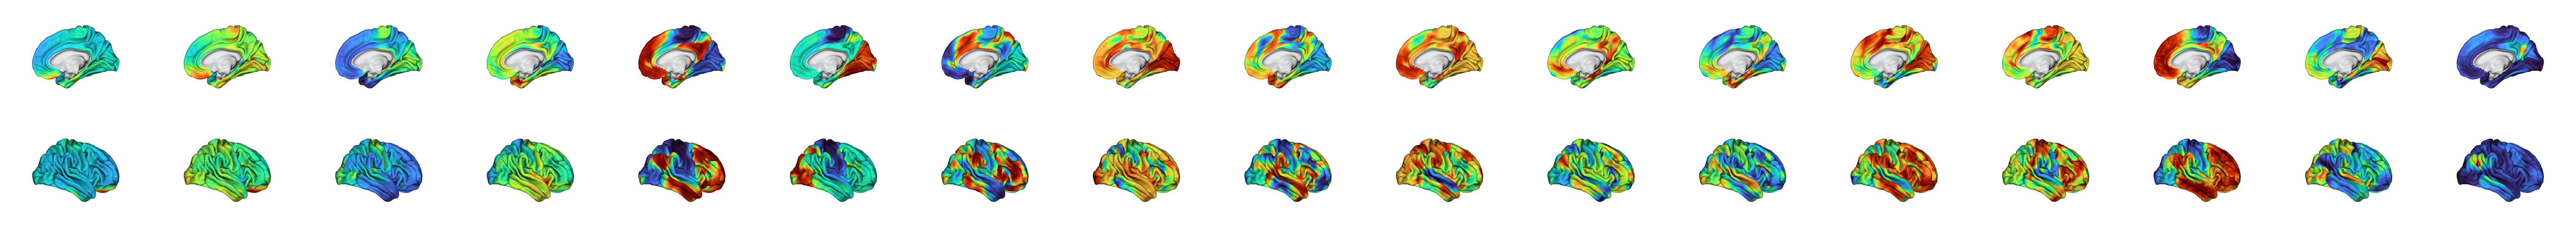

In [70]:
# plot maps
print(maps, [neuromaps_names[i][1] for i in range(len(neuromaps_names))])
fig = plot_surf(surf={'lh': surf}, data={'lh': unmask_data(all_data, medmask)}, views=['lateral', 'medial'], layout_indiv='col', layout_group='row')
fig.show(jupyter_backend='static')

In [73]:
all_data_corr = np.corrcoef(all_data, rowvar=False)
all_data_corrw = 1-cdistw(all_data, all_data, solver.mass, metric='correlation')

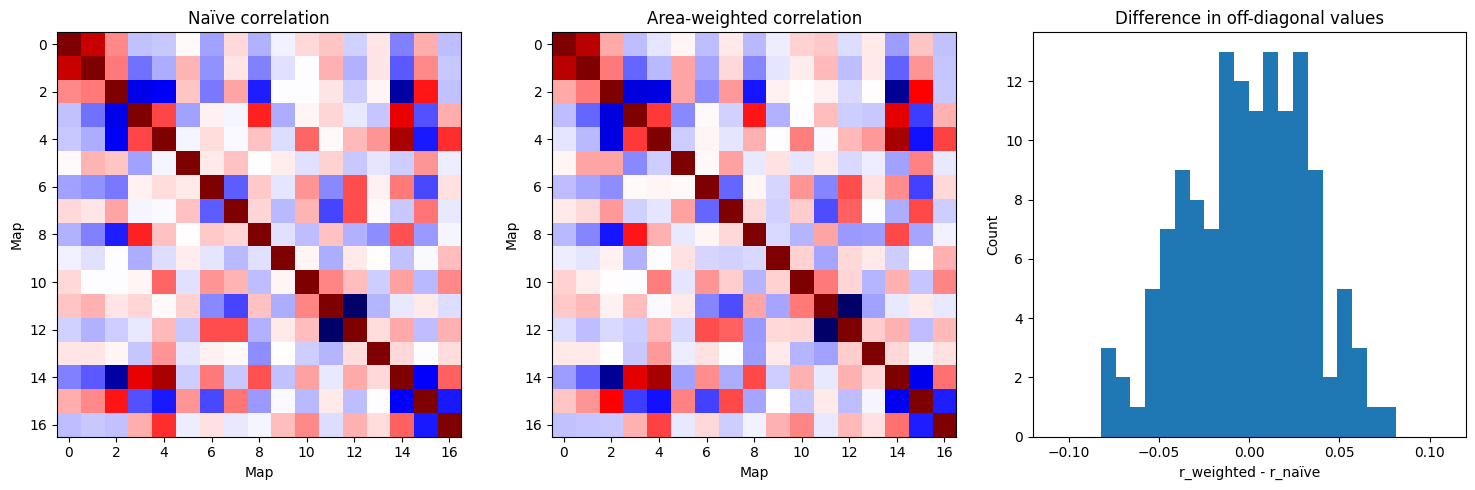

In [74]:
# three subplots: unweighted correlation, weighted correlation, and distribution of off-diag
# differences between the two
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
im0 = axs[0].imshow(all_data_corr, vmin=-1, vmax=1, cmap='seismic')
axs[0].set_title('Naïve correlation')
axs[0].set_xlabel('Map')
axs[0].set_ylabel('Map')
im1 = axs[1].imshow(all_data_corrw, vmin=-1, vmax=1, cmap='seismic')
axs[1].set_title('Area-weighted correlation')
axs[1].set_xlabel('Map')
axs[1].set_ylabel('Map')
diff = all_data_corrw - all_data_corr
axs[2].hist(diff[np.triu_indices_from(diff, k=1)], bins=20)
axs[2].set_title('Difference in off-diagonal values')
axs[2].set_xlim(-0.12, 0.12)
axs[2].set_xlabel('r_weighted - r_naïve')
axs[2].set_ylabel('Count')
plt.tight_layout()
plt.show()

### 4k maps

In [77]:
surf_4k, medmask_4k = fetch_surf(density='4k', hemi='R')
solver_4k = EigenSolver(surf_4k, mask=medmask_4k).compute_lbo()

In [84]:
maps_4k = ['thickness', 'myelinmap', 'genel4PC1', 'ndi', 'odi', 'sv2a', 'flumazenil']
all_data_4k = np.stack([load(f'C:/Users/ipop0003/victor_data/sp-human_tpl-fsLR_den-4k_hemi-L_{map_name}.func.gii').darrays[0].data[medmask_4k] for map_name in maps_4k], axis=1)
neuromaps_4k_names = available_annotations(den='4k', hemi='R')
neuromaps_4k_annots = [fetch_annotation(den='4k', hemi='R', verbose=0)[name] for name in neuromaps_4k_names]
data_neuromaps_4k = np.stack([load(neuromaps_4k_annots[i]).darrays[0].data[medmask_4k] for i in range(len(neuromaps_4k_names))], axis=1)
all_data_4k = np.concatenate([all_data_4k, data_neuromaps_4k], axis=1)

['ndi', 'odi'] ['megalpha', 'megbeta', 'megdelta', 'meggamma1', 'meggamma2', 'megtheta', 'megtimescale']


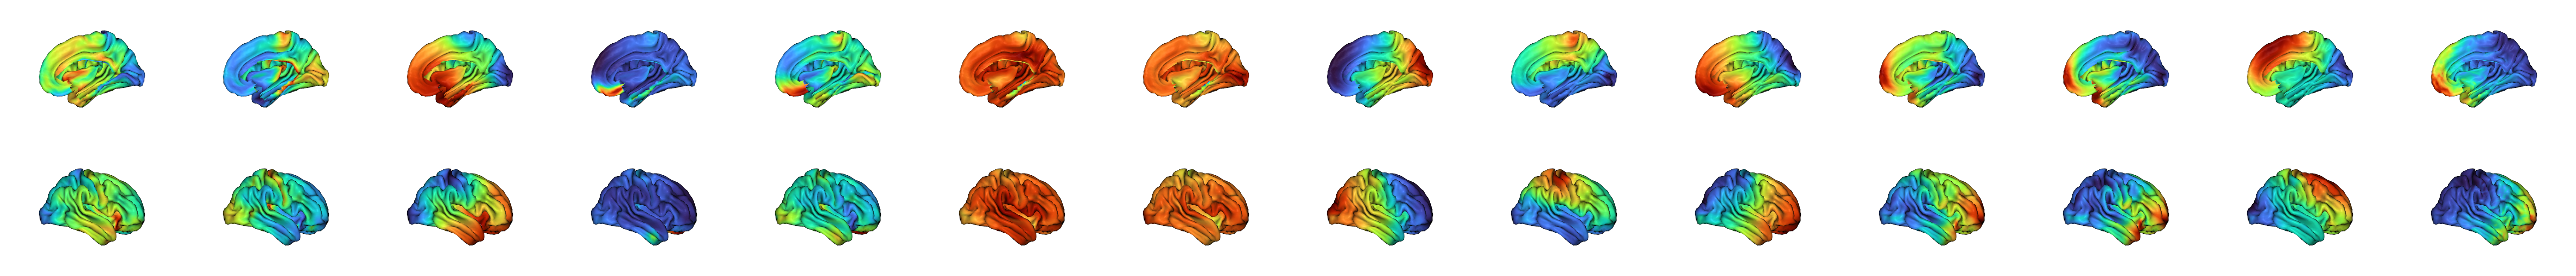

In [85]:
# plot maps
print(maps, [neuromaps_4k_names[i][1] for i in range(len(neuromaps_4k_names))])
fig = plot_surf(surf={'lh': solver_4k.geometry}, data={'lh': all_data_4k}, views=['lateral', 'medial'], layout_indiv='col', layout_group='row')
fig.show(jupyter_backend='static')

In [86]:
all_data_4k = data_neuromaps_4k  # just look at neuromaps for now
all_data_4k_corr = np.corrcoef(all_data_4k, rowvar=False)
all_data_4k_corrw = 1-cdistw(all_data_4k, all_data_4k, solver_4k.mass, metric='correlation')

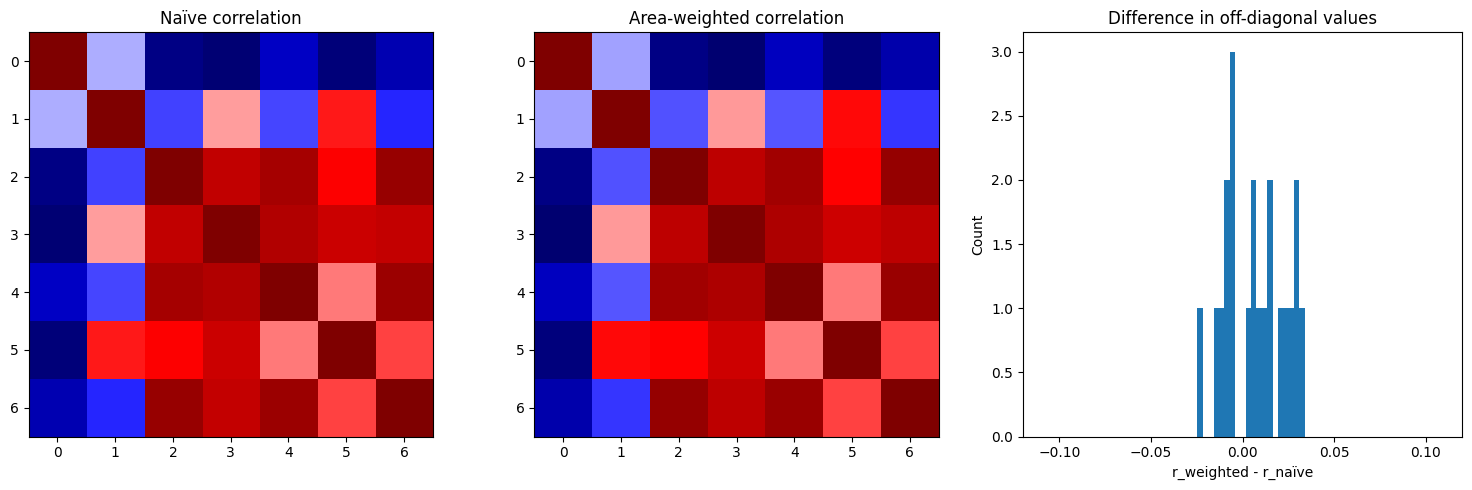

In [87]:
# three subplots: unweighted correlation, weighted correlation, and distribution of off-diag
# differences between the two
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
im0 = axs[0].imshow(all_data_4k_corr, vmin=-1, vmax=1, cmap='seismic')
axs[0].set_title('Naïve correlation')
im1 = axs[1].imshow(all_data_4k_corrw, vmin=-1, vmax=1, cmap='seismic')
axs[1].set_title('Area-weighted correlation')
diff = all_data_4k_corrw - all_data_4k_corr
axs[2].hist(diff[np.triu_indices_from(diff, k=1)], bins=20)
axs[2].set_title('Difference in off-diagonal values')
axs[2].set_xlim(-0.12, 0.12)
axs[2].set_xlabel('r_weighted - r_naïve')
axs[2].set_ylabel('Count')
plt.tight_layout()
plt.show()

### 164k maps

In [88]:
# get maps
neuromaps_164k_names = available_annotations(den='164k', hemi='R')
neuromaps_164k_annots = [fetch_annotation(den='164k', hemi='R', verbose=0)[name] for name in neuromaps_164k_names]
all_data_164k = np.stack([load(neuromaps_164k_annots[i]).darrays[0].data for i in range(len(neuromaps_164k_names))], axis=1)

# infer medmask by taking intersection of nonzero vertices across all maps
medmask_164k = np.loadtxt('C:/Users/ipop0003/neuromodes/neuromodes/data/fsaverage_164k_cortex-rh_mask.txt', dtype=bool)
all_data_164k = all_data_164k[medmask_164k, :]

In [89]:
surf_164k = 'C:/Users/ipop0003/neuromodes/neuromodes/data/fsaverage_164k_midthickness-rh.vtk'
solver_164k = EigenSolver(surf_164k).compute_lbo()
mass_164k = _mask_fem_matrices(mass=solver_164k.mass, mask=medmask_164k)[0]

C:\Users\ipop0003\nsbutils\nsbutils\plotting_pyvista.py:396: PyVistaFutureWarning: The default value of `algorithm` for the filter
`PolyData.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  poly = poly.extract_surface().triangulate()


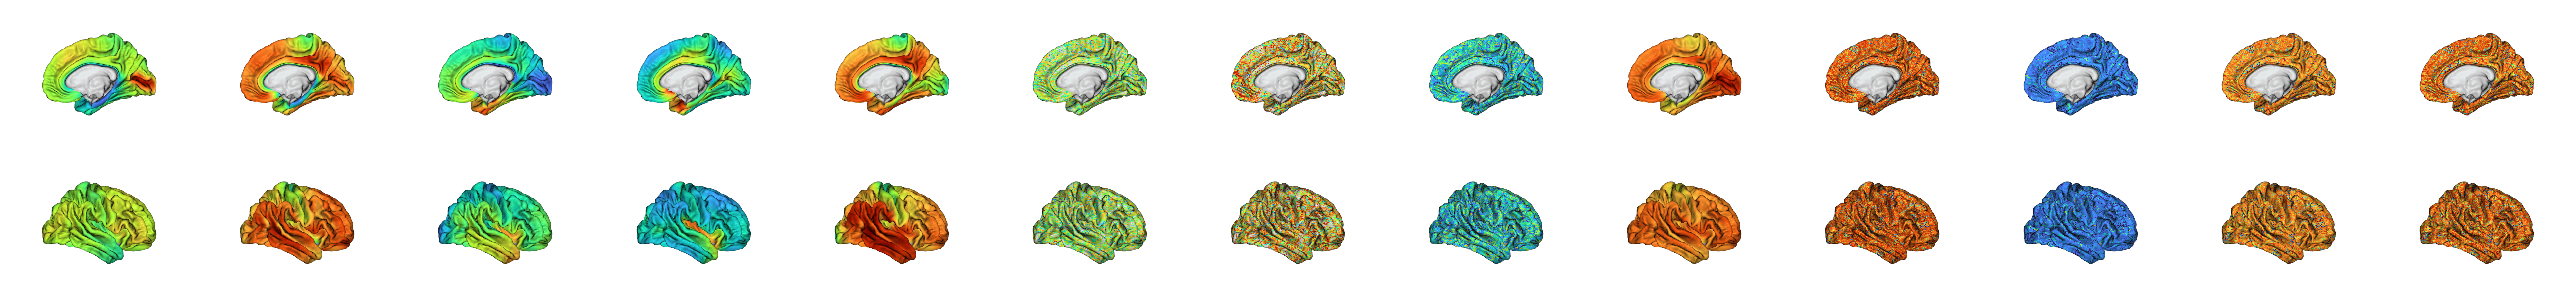

In [90]:
# plot maps
fig = plot_surf(surf={'lh': surf_164k}, data={'lh': unmask_data(all_data_164k, medmask_164k)}, views=['lateral', 'medial'], layout_indiv='col', layout_group='row')
fig.show(jupyter_backend='static')

In [91]:
all_data_164k_corr = np.corrcoef(all_data_164k, rowvar=False)
all_data_164k_corrw = 1-cdistw(all_data_164k, all_data_164k, mass_164k, metric='correlation')

In [ ]:
# find largest difference between weighted and unweighted correlations
diff_164k = all_data_164k_corrw - all_data_164k_corr
max_diff = np.nanmax(np.abs(diff_164k))
max_diff_idx = np.unravel_index(np.nanargmax(np.abs(diff_164k)), diff_164k.shape)
max_diff_idx  # this is .103, corresponding to beliveau2017-cumi101 and norgaard2021-flumazenil

(np.int64(2), np.int64(8))

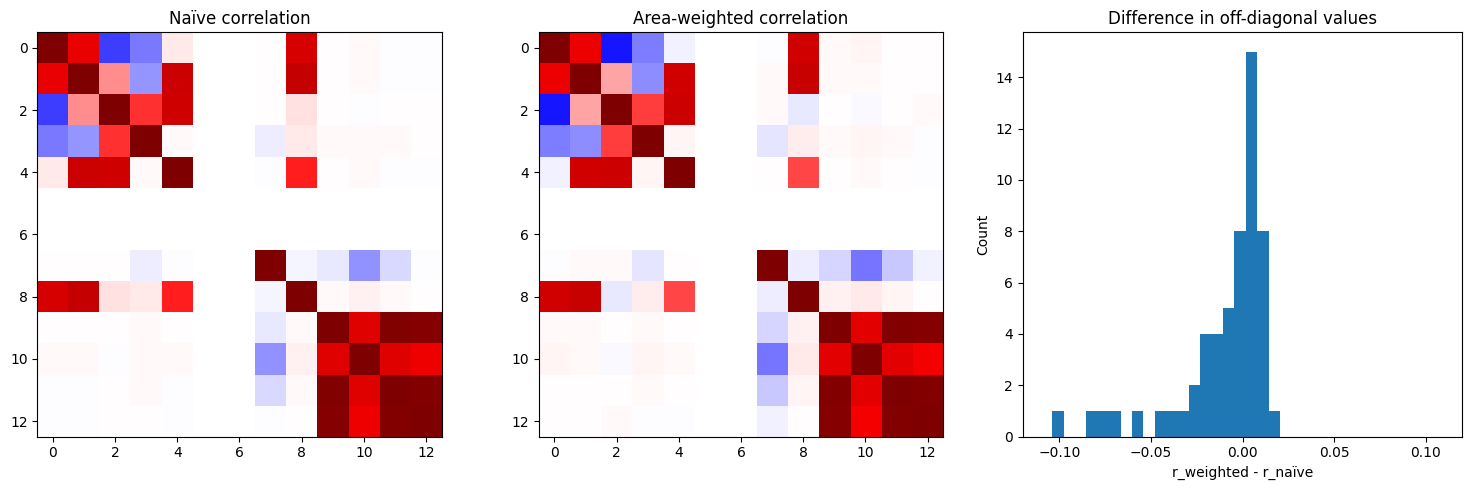

In [92]:
# three subplots: unweighted correlation, weighted correlation, and distribution of off-diag
# differences between the two
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
im0 = axs[0].imshow(all_data_164k_corr, vmin=-1, vmax=1, cmap='seismic')
axs[0].set_title('Naïve correlation')
im1 = axs[1].imshow(all_data_164k_corrw, vmin=-1, vmax=1, cmap='seismic')
axs[1].set_title('Area-weighted correlation')
diff = all_data_164k_corrw - all_data_164k_corr
axs[2].hist(diff[np.triu_indices_from(diff, k=1)], bins=20)
axs[2].set_title('Difference in off-diagonal values')
axs[2].set_xlim(-0.12, 0.12)
axs[2].set_xlabel('r_weighted - r_naïve')
axs[2].set_ylabel('Count')
plt.tight_layout()
plt.show()

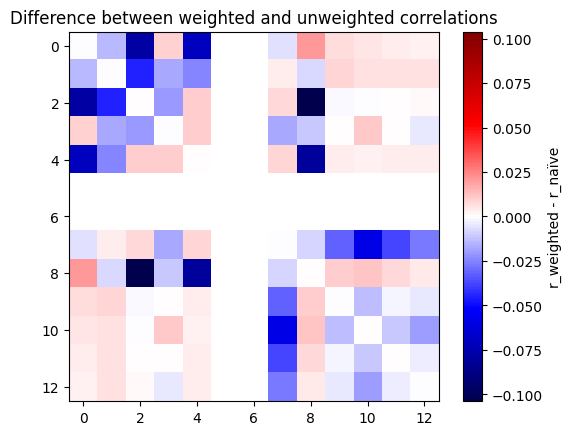

In [102]:
# plot difference matrix
plt.imshow(diff, vmin=-max_diff, vmax=max_diff, cmap='seismic')
plt.title('Difference between weighted and unweighted correlations')
plt.colorbar(label='r_weighted - r_naïve')
plt.show()

### Fine, we'll just do modes

In [62]:
solver.solve(100)
emodes = solver.emodes[:, 1:]

In [65]:
all_modes_corr = np.corrcoef(emodes, rowvar=False)
all_modes_corrw = 1-cdistw(emodes, emodes, solver.mass, metric='correlation')

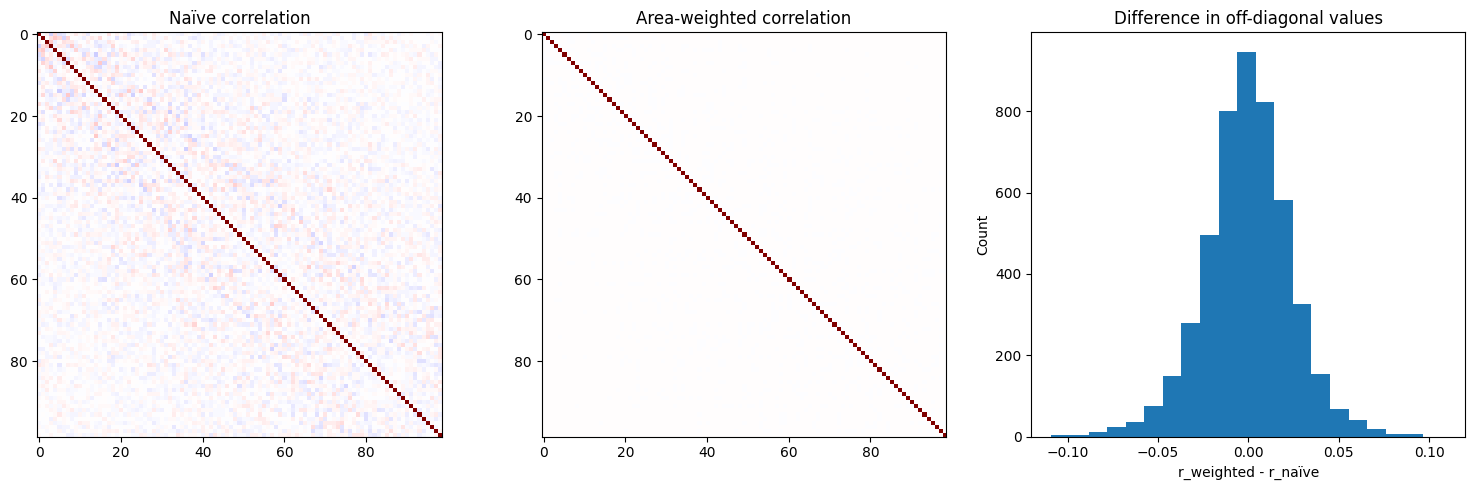

In [67]:
# three subplots: unweighted correlation, weighted correlation, and distribution of off-diag
# differences between the two
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
im0 = axs[0].imshow(all_modes_corr, vmin=-1, vmax=1, cmap='seismic')
axs[0].set_title('Naïve correlation')
im1 = axs[1].imshow(all_modes_corrw, vmin=-1, vmax=1, cmap='seismic')
axs[1].set_title('Area-weighted correlation')
diff = all_modes_corrw - all_modes_corr
axs[2].hist(diff[np.triu_indices_from(diff, k=1)], bins=20)
axs[2].set_title('Difference in off-diagonal values')
axs[2].set_xlim(-0.12, 0.12)
axs[2].set_xlabel('r_weighted - r_naïve')
axs[2].set_ylabel('Count')
plt.tight_layout()
plt.show()